# Decoding Nike’s Customer Sentiment on Reddit

## A Machine Learning Approach to understanding the Customer

Amelia Farrell
4/14/25



In [2]:
# Connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

# Change to the google drive directory
%cd /content/drive/MyDrive/Colab\ Notebooks/DSC550

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/DSC550


In [3]:
pip install praw pandas nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 10.7 MB/s eta 0:00:00


In [4]:
# Libaraies needed
import praw
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
from datetime import datetime
import time

# 1. Data Collection | API Connection

We will be pulling data from Reddit using their API (https://www.reddit.com/prefs/apps) from the start of 2022 to March of 2025. Detailed steps are listed below within code comments. We have saved the final output to a csv for access after inital pull.

In [ ]:
# Step 1: Authenticate with Reddit API
reddit = praw.Reddit(
    client_id='NyFvKaOaEyT7JR2vWlpxtQ',
    client_secret='ZAqn-IVC5_7-1QbGb35whdMG4V7dgA',
    user_agent='Amelia'
)

# Step 2: Choose the Subreddit and Search Query
subreddit_name = 'all'  # Subreddit ('all' will include any)
search_query = 'Nike'   # Keyword search (all posts & comments containing the word (case-insensitive)

# Define date range (Unix timestamps)
start_date = int(datetime(2022, 1, 1).timestamp())  # Start of 2022
end_date = int(datetime(2025, 12, 31, 23, 59, 59).timestamp())  # End of 2025

# Step 3: Collect Reddit Data with date filtering
data = []
max_posts = 1000  # Set a reasonable upper limit to avoid infinite loops

for post in reddit.subreddit(subreddit_name).search(search_query, limit=max_posts):
    post_time = int(post.created_utc)

    # Only include posts within our date range
    if start_date <= post_time <= end_date:
        post_data = {
            'title': post.title,
            'selftext': post.selftext,
            'upvotes': post.score,
            'url': post.url,
            'date': datetime.utcfromtimestamp(post.created_utc).strftime('%Y-%m-%d %H:%M:%S'),
            'comments': []
        }

        # Collecting comments for each post
        post.comments.replace_more(limit=0)
        for comment in post.comments.list():
            post_data['comments'].append(comment.body)

        data.append(post_data)

    # Optional: Add small delay to avoid rate limiting
    time.sleep(0.5)

# Convert to DataFrame
df = pd.DataFrame(data)
print(f"Collected {len(df)} posts from 2022 to 2025")

# Save to CSV
df.to_csv('reddit_nike_data_2022_2025.csv', index=False)
print("Data saved to 'reddit_nike_data_2022_2025.csv'.")

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

Collected 119 posts from 2022 to 2025
Data saved to 'reddit_nike_data_2022_2025.csv'.


# 2. EDA & Data Transformations

Now that we have our data. We need to understand it's structure and transform it where needed for our sentiment anaylsis.

In [52]:
# loading data
import pandas as pd
df = pd.read_csv('reddit_nike_data_2022_2025.csv')

In [53]:
# View Data
df = pd.DataFrame(df)
df.head(5)

,title,selftext,upvotes,url,date,comments
0,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,['Important Links & Active Giveaways\n\n[Begin...
1,Best Nike clothes sellers?,Looking for good Nike sellers for clothes,144,https://i.redd.it/lqup9bsn9n8e1.jpeg,2024-12-23 18:49:43,['Important Links & Active Giveaways\n\n\n[All...
2,NIKE yolo,"I’m not personally a big fan of Nike gear, but...",34,https://i.redd.it/0ptn8a1a0wpe1.jpeg,2025-03-20 18:23:27,['\n**User Report**| | | |\n:--|:--|:--|:--\n*...
3,Trump's massive 46% Vietnam tariffs could hit ...,NaN,6998,https://www.cnbc.com/2025/04/02/trump-tariffs-...,2025-04-03 2:37:50,NaN
4,Just saw a Nike exec fall down to his knees.,NaN,15948,https://streamable.com/8v3vpl,2024-11-25 14:33:16,NaN


In [54]:
# Count the number of rows
len(df)

116

In [55]:
import pandas as pd
import ast

# Convert string representations of lists to actual lists
df['comments'] = df['comments'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) and x != 'nan' else [])

# Explode the comments into separate rows
df_expanded = df.explode('comments').reset_index(drop=True)

# Rename the 'comments' column to 'comment' for clarity
df_expanded = df_expanded.rename(columns={'comments': 'comment'})

# Reorder columns for clarity
columns = ['title', 'selftext', 'upvotes', 'url', 'date', 'comment']
df_expanded = df_expanded[columns]

In [56]:
df_expanded.head(5)

,title,selftext,upvotes,url,date,comment
0,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,Important Links & Active Giveaways\n\n[Beginne...
1,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,nike is sending a nuclear warhead to your hous...
2,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,Nice haul but the problem with the Nike off wh...
3,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,Bro got the infinity stone lineup lmao
4,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,how did this not get seized 😭😭


In [57]:
# Count the number of rows
len(df_expanded)

18029

In [58]:
# Group by 'title' and count unique comments (excluding NaN)
unique_comments_per_title = df_expanded.groupby('title')['comment'].nunique()

# Calculate average, max, and min of unique comments per title
average_unique_comments = unique_comments_per_title.mean()
max_unique_comments = unique_comments_per_title.max()
min_unique_comments = unique_comments_per_title.min()

# Print the results
print(f"Average number of unique comments per title: {average_unique_comments:.2f}")
print(f"Maximum number of unique comments for a title: {max_unique_comments}")
print(f"Minimum number of unique comments for a title: {min_unique_comments}")

Average number of unique comments per title: 152.20
Maximum number of unique comments for a title: 485
Minimum number of unique comments for a title: 0


In [59]:
# Group by 'title' and check if all comments are NaN (indicating 0 comments)
titles_with_comments = df_expanded.groupby('title')['comment'].apply(lambda x: x.isna().all())

# Count the number of titles with 0 comments (where all comments are NaN)
titles_with_zero_comments = titles_with_comments.sum()

# Print the result
print(f"Number of titles with 0 comments: {titles_with_zero_comments}")

Number of titles with 0 comments: 34


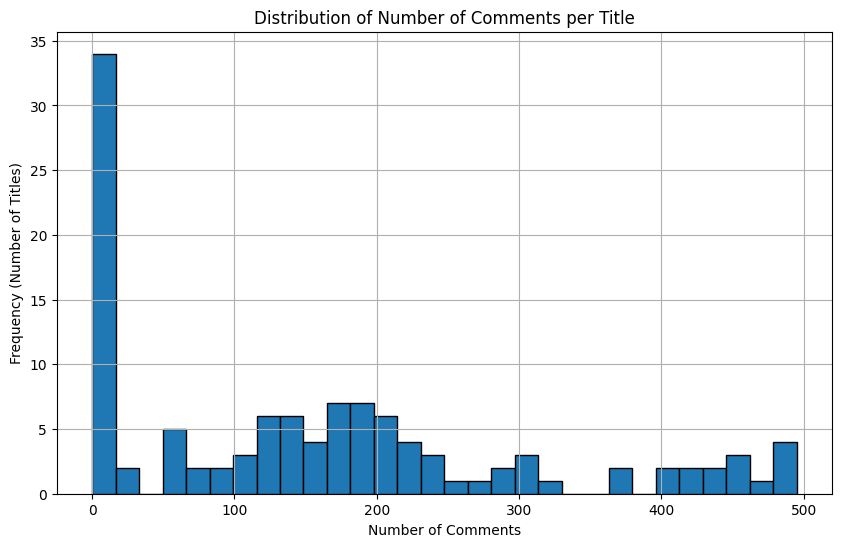

In [60]:
import matplotlib.pyplot as plt

# Group by 'title' and count the number of comments per title (non-NaN comments)
comments_per_title = df_expanded.groupby('title')['comment'].count()

# Create a histogram of the number of comments per title
plt.figure(figsize=(10, 6))
plt.hist(comments_per_title, bins=30, edgecolor='black')
plt.title('Distribution of Number of Comments per Title')
plt.xlabel('Number of Comments')
plt.ylabel('Frequency (Number of Titles)')
plt.grid(True)

In [61]:
# Function to check if "Nike" is in the comment (case-insensitive)
def contains_nike(comment):
    if pd.isna(comment) or comment == '':
        return False
    return 'nike' in str(comment).lower()

# Add a new column 'has_nike' to flag comments containing "Nike"
df_expanded['has_nike'] = df_expanded['comment'].apply(contains_nike)

# Print the number of rows flagged as containing "Nike"
nike_flagged_count = df_expanded['has_nike'].sum()
print(f"Number of comments flagged as containing 'Nike': {nike_flagged_count}")

Number of comments flagged as containing 'Nike': 1948


In [62]:
# Save the updated DataFrame to a new CSV
df_expanded.to_csv('reddit_nike_data_with_nike_flag.csv', index=False)

In [4]:
# loading data if needed
import pandas as pd
df_expanded = pd.read_csv('reddit_nike_data_with_nike_flag.csv')

In [5]:
df_expanded.head(5)

,title,selftext,upvotes,url,date,comment,has_nike
0,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,Important Links & Active Giveaways\n\n[Beginne...,False
1,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,nike is sending a nuclear warhead to your hous...,True
2,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,Nice haul but the problem with the Nike off wh...,True
3,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,Bro got the infinity stone lineup lmao,False
4,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,how did this not get seized 😭😭,False


<ipython-input-8-c6b4081c253c>:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_expanded[df_expanded['has_nike'] == True], label='Has Nike', fill=True, alpha=0.5)
<ipython-input-8-c6b4081c253c>:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_expanded[df_expanded['has_nike'] == False], label='No Nike', fill=True, alpha=0.5)


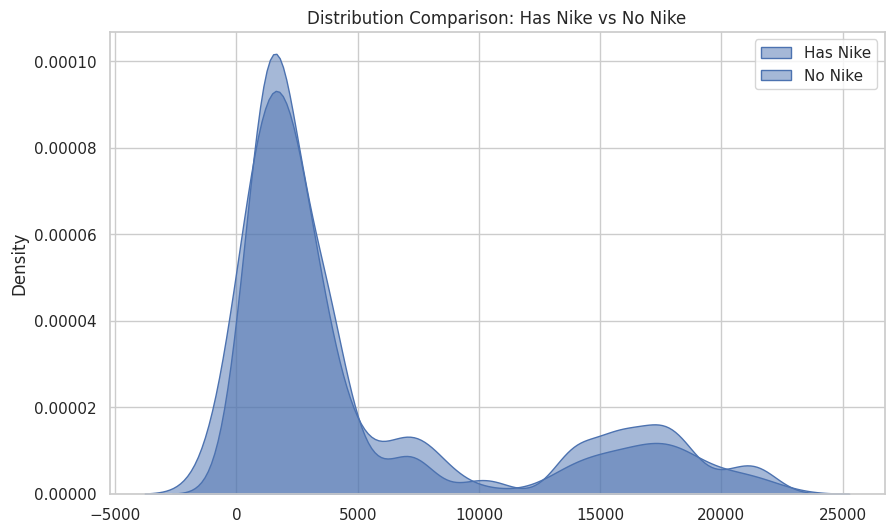

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set(style="whitegrid")

# Plot the overlapping distributions
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_expanded[df_expanded['has_nike'] == True], label='Has Nike', fill=True, alpha=0.5)
sns.kdeplot(data=df_expanded[df_expanded['has_nike'] == False], label='No Nike', fill=True, alpha=0.5)

plt.title('Distribution Comparison: Has Nike vs No Nike')
plt.xlabel('')
plt.ylabel('Density')
plt.legend()
plt.show()

In [67]:
# Count the number of comments that contain the word "nike" by using the the 'has nike' column
df_expanded['has_nike'].value_counts()

counts = df_expanded['has_nike'].value_counts()
print(counts)

has_nike
False    16081
True      1948
Name: count, dtype: int64


It appears that we have alot of comments on the Nike related threads that do not mention the word "Nike". We want to understand if these comments are unrelated and should be removed from our anaylsis. We will do so by filtering on the comments without the word "Nike" and viewing the frist 10 as a spot check.

In [70]:
df_no_nike_comments = df_expanded[df_expanded['has_nike'] == False][['comment']]
df_no_nike_comments.head(10)

,comment
0,Important Links & Active Giveaways\n\n[Beginne...
3,Bro got the infinity stone lineup lmao
4,how did this not get seized 😭😭
6,"Hey Bro, Amazing Haul. I'm from the UK. I want..."
7,https://preview.redd.it/9ddt0cbje6qd1.jpeg?wid...
8,"Hello, I am anonymous. Thank you for your supp..."
9,Those J1 Voodoo Zions are such an underrated p...
10,wait what did u yse to ship it out?
11,One of the greatest shoe hauls of all time. Am...
12,I have a pair of the blue and white UNC’s. Per...


As you can see, most of the comments without the word "Nike" are still shoe related. Such as "Hey Bro, Amazing Haul" and "I have a pair of the blue and white UNC’s". These are positive comments still related to Nike that we want to ensure that we keep. We could consider filtering out all comments that do not mention shoe related key words, such as "size", "blue", "fit", "running", etc. but there are many words and slang that we could miss, so all comments will be left in for now.

# 3. Sentiment Analysis (nltk, VADER)

We will be using nltk's VADER for analyzing the sentiment of each of the columns. VADER (Valence Aware Dictionary and sEntiment Reasoner) is optimized for social media text like Reddit, helping capturing nuances such as slang, emojis, and informal language. Making it the perfect fit for our data and project goal.

In [71]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [72]:
from nltk.sentiment import SentimentIntensityAnalyzer

# Initialize the SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Function to calculate sentiment score for a comment
def get_sentiment(comment):
    if pd.isna(comment) or comment == '':
        return 0.0  # Neutral score for NaN or empty comments
    sentiment = sia.polarity_scores(comment)
    return sentiment['compound']  # Return the compound score (-1 to 1)

# Apply sentiment analysis to each comment and create a new column
df_expanded['sentiment_score'] = df_expanded['comment'].apply(get_sentiment)

In [73]:
df_expanded.head(5)

,title,selftext,upvotes,url,date,comment,has_nike,sentiment_score
0,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,Important Links & Active Giveaways\n\n[Beginne...,False,0.7003
1,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,nike is sending a nuclear warhead to your hous...,True,0.0000
2,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,Nice haul but the problem with the Nike off wh...,True,-0.7783
3,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,Bro got the infinity stone lineup lmao,False,0.5994
4,My first haul. 11 pairs of Nike. 18kg,Hi all. \n\nQuick review of my first haul. \n\...,1264,https://www.reddit.com/gallery/1fm3xj0,2024-09-21 14:11:42,how did this not get seized 😭😭,False,0.0000


In [166]:
# Save the updated DataFrame with sentiment scores to a new CSV
df_expanded.to_csv('reddit_nike_data_with_sentiment.csv', index=False)

In [23]:
# re-loading if needed
import pandas as pd
df_expanded = pd.read_csv('reddit_nike_data_with_sentiment.csv')

In [188]:
print(f"Number of rows in DataFrame: {df_expanded.shape[0]}")

total_post_sentiment = df_expanded['sentiment_score'].sum()
print(f"Total sum of sentiment: {total_post_sentiment}")

Number of rows in DataFrame: 17796
Total sum of sentiment: 1939.4978


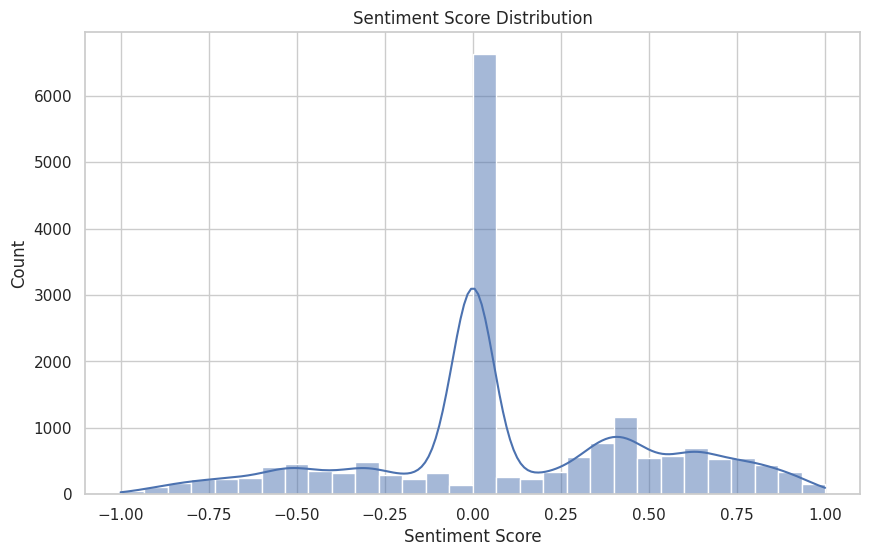

In [189]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the sentiment score distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df_expanded, x='sentiment_score', bins=30, kde=True)

# Label the plot
plt.title('Sentiment Score Distribution')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.show()

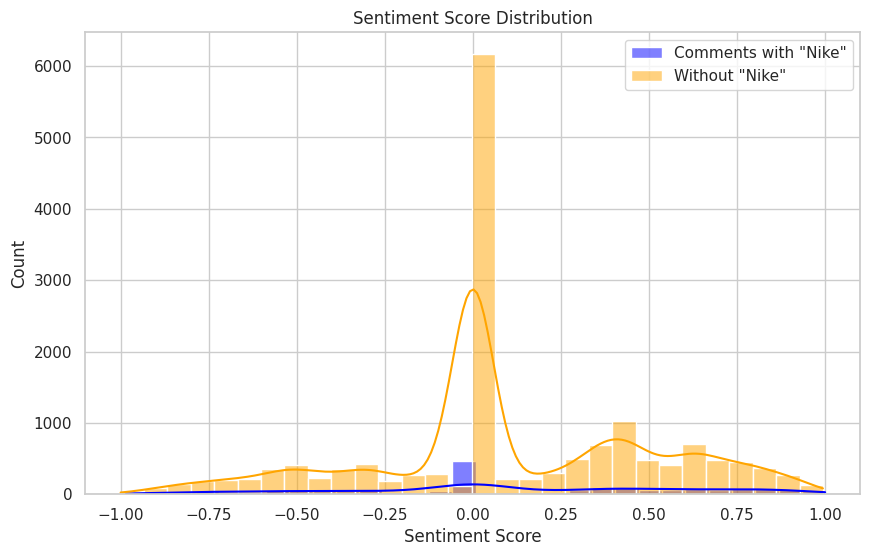

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
sns.histplot(data=df_expanded[df_expanded['has_nike'] == True],
             x='sentiment_score',
             color='blue',
             label='Comments with "Nike"',
             kde=True,
             bins=30,
             alpha=0.5)

sns.histplot(data=df_expanded[df_expanded['has_nike'] == False],
             x='sentiment_score',
             color='orange',
             label='Without "Nike"',
             kde=True,
             bins=30,
             alpha=0.5)

# Labels and legend
plt.title('Sentiment Score Distribution')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.legend()
plt.show()


In [191]:
avg_scores = df_expanded.groupby('has_nike')['sentiment_score'].mean()
print(avg_scores)

has_nike
False    0.106244
True     0.131892
Name: sentiment_score, dtype: float64


In [193]:
# Filter out rows with sentiment_score == 0
filtered_df = df_expanded[df_expanded['sentiment_score'] != 0]

# Calculate average sentiment score by has_nike
avg_scores_filtered = filtered_df.groupby('has_nike')['sentiment_score'].mean()
print(avg_scores_filtered)

has_nike
False    0.171314
True     0.171586
Name: sentiment_score, dtype: float64


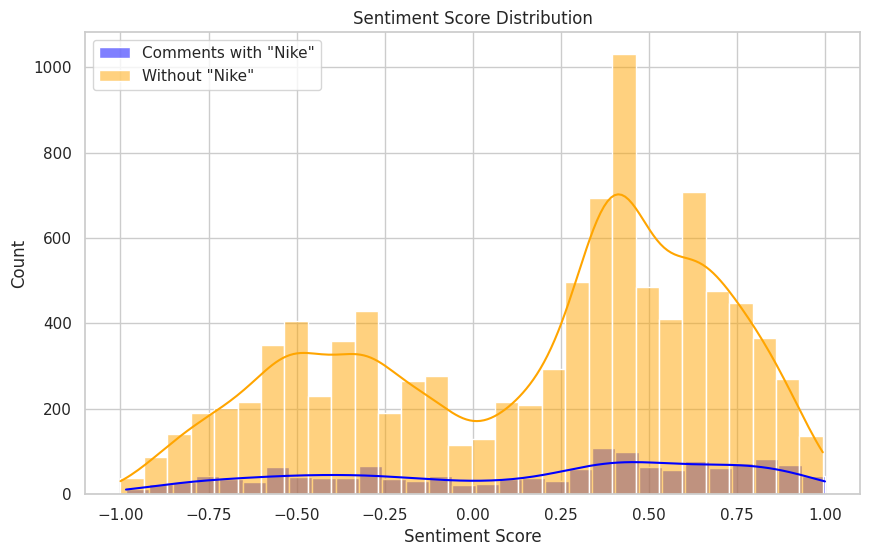

In [194]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_df[filtered_df['has_nike'] == True],
             x='sentiment_score',
             color='blue',
             label='Comments with "Nike"',
             kde=True,
             bins=30,
             alpha=0.5)

sns.histplot(data=filtered_df[filtered_df['has_nike'] == False],
             x='sentiment_score',
             color='orange',
             label='Without "Nike"',
             kde=True,
             bins=30,
             alpha=0.5)

# Labels and legend
plt.title('Sentiment Score Distribution')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.legend()
plt.show()

In [195]:
# Save filtered DataFrame
filtered_df.to_csv('reddit_nike_data_with_sentiment_filtered.csv', index=False)

In [9]:
# re-loading if needed
import pandas as pd
filtered_df = pd.read_csv('reddit_nike_data_with_sentiment_filtered.csv')

In [10]:
print(f"Number of rows in DataFrame: {filtered_df.shape[0]}")

total_post_sentiment = filtered_df['sentiment_score'].sum()
print(f"Total sum of sentiment: {total_post_sentiment}")

Number of rows in DataFrame: 11319
Total sum of sentiment: 1939.4978


When excluding neutral comments (sentiment_score = 0) comments that contain Nike or not sore about the same (has_nike, False = 0.175262, True = 0.184734). Further showing the importance of keeping the False Nike comments but showing that the neutral ones are not needed.

<ipython-input-196-b255c56bb028>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['date'] = pd.to_datetime(filtered_df['date'])
<ipython-input-196-b255c56bb028>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['year_month'] = filtered_df['date'].dt.to_period('M').astype(str)


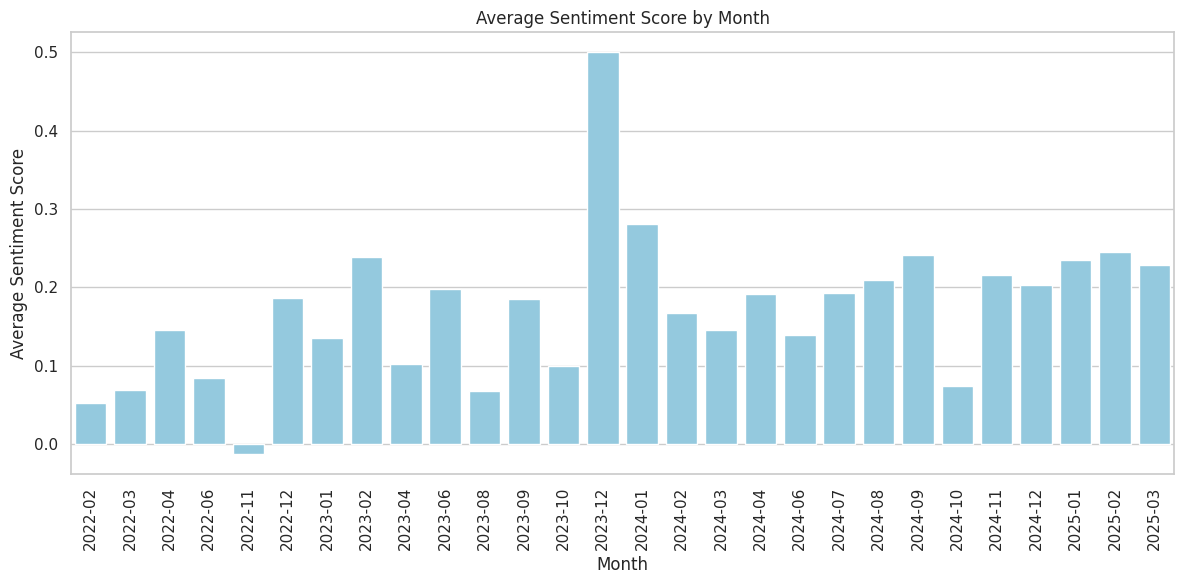

In [196]:
# Ensuring 'date' is in datetime format
filtered_df['date'] = pd.to_datetime(filtered_df['date'])

# Create a new column for year-month
filtered_df['year_month'] = filtered_df['date'].dt.to_period('M').astype(str)

# Group by year_month and calculate the average sentiment score
monthly_avg = filtered_df.groupby('year_month')['sentiment_score'].mean().reset_index()

# Plot the monthly averages as a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_avg, x='year_month', y='sentiment_score', color='skyblue')

plt.title('Average Sentiment Score by Month')
plt.xlabel('Month')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Overall it looks good. But what happed in November 2022?

In [197]:
# Convert 'date' column to datetime
filtered_df['date'] = pd.to_datetime(filtered_df['date'])

# Filter rows for November 2022
nov_2022_df = filtered_df[filtered_df['date'].dt.month == 11]
nov_2022_df = nov_2022_df[nov_2022_df['date'].dt.year == 2022]

# Sort by sentiment_score and select the top 10 lowest
top_10_lowest_nov_2022 = nov_2022_df.nsmallest(10, 'sentiment_score')

# Show the result
print(top_10_lowest_nov_2022[['title', 'sentiment_score', 'comment']])

                                         title  sentiment_score  \
4265  Nike ends Relationship With Kyrie Irving          -0.9747   
4215  Nike ends Relationship With Kyrie Irving          -0.9565   
4117  Nike ends Relationship With Kyrie Irving          -0.9407   
4234  Nike ends Relationship With Kyrie Irving          -0.9350   
2619      A Nike sewing error on a $100 hoodie          -0.9315   
4165  Nike ends Relationship With Kyrie Irving          -0.9244   
4092  Nike ends Relationship With Kyrie Irving          -0.9204   
4007  Nike ends Relationship With Kyrie Irving          -0.9153   
2240      A Nike sewing error on a $100 hoodie          -0.9072   
4105  Nike ends Relationship With Kyrie Irving          -0.8928   

                                                comment  
4265  see what I'm saying, you are gaslighting right...  
4215  Ah yes... His fake cry face....\n\nPeople sure...  
4117  Because he's a troll. Don't engage or better y...  
4234  Yeah man. People who don

<ipython-input-197-5c5602ec8027>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['date'] = pd.to_datetime(filtered_df['date'])


This shows us that people really did not like how Nike ended their Relationship with Kyrie Irving (American basketball player). Showing just how much some customers weigh Nike’s sponsorships when choosing a brand. This could indicate that a bring back of Kyrie Irving or new sponsorships could potentially reignite some interest in the brand.

People also complained about a sewing error on a $100 hoodie in November 2022. Showing how much quality control for high priced items is important to customers.

But what did people like so much in December 2023, the very next year?

In [199]:
# Convert 'date' column to datetime
filtered_df['date'] = pd.to_datetime(filtered_df['date'])

# Filter rows for dec 2023
dec_2023_df = filtered_df[filtered_df['date'].dt.month == 12]
dec_2023_df = dec_2023_df[dec_2023_df['date'].dt.year == 2023]

# Sort by sentiment score and select the top 10 lowest
top_10_highest_dec_2023 = dec_2023_df.nlargest(10, 'sentiment_score')

# Show the result
print(top_10_highest_dec_2023[['title', 'sentiment_score', 'comment', 'url']])

                                            title  sentiment_score  \
16285  Made a Nike AI Spec Commercial by Accident           0.9810   
16143  Made a Nike AI Spec Commercial by Accident           0.9713   
16206  Made a Nike AI Spec Commercial by Accident           0.9643   
16126  Made a Nike AI Spec Commercial by Accident           0.9615   
16333  Made a Nike AI Spec Commercial by Accident           0.9561   
16181  Made a Nike AI Spec Commercial by Accident           0.9545   
16245  Made a Nike AI Spec Commercial by Accident           0.9459   
16335  Made a Nike AI Spec Commercial by Accident           0.9348   
16177  Made a Nike AI Spec Commercial by Accident           0.9217   
16326  Made a Nike AI Spec Commercial by Accident           0.9117   

                                                 comment  \
16285  Feels like a multi million dollar project that...   
16143  Just for clarity what happens next OP? I get i...   
16206  I hope to see this on billboards on timesq

<ipython-input-199-5a77a0767528>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['date'] = pd.to_datetime(filtered_df['date'])


It appears that the AI generated Nike add had alot of positive feedback that month.

# 3. Topic Modeling with BERTopic

Now that we understand that general distribution of Nike sentiment on Reddit since 2022. We can begin to dig deeper into why people feel the way they do and what Nike should focus on (or not) to increase customer satisfaction and sales.

One way we can do this is through Topic Modeling. Meaning the discovey of the most common discussion topics. We will use BERTopic, which is a powerful topic modeling tool that leverages transformers for creating interpretable topics from text data. BERTopic also uses dimensionality reduction techniques like UMAP for creating clusters of similar documents, followed by clustering these topics with HDBSCAN.

In [5]:
# Reloading if needed
import pandas as pd
filtered_df = pd.read_csv('reddit_nike_data_with_sentiment_filtered.csv')

In [ ]:
# BERTopic libraries
!pip install bertopic umap-learn hdbscan

Preprocessing comments for BERTopic

In [35]:
# libraries needed for this section
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
import string
import re
import kaleido

In [14]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [16]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [26]:
# Load stop words list
stop_words = set(stopwords.words('english'))

# Load stop words list
stop_words = set(stopwords.words('english'))

# Custom list of words to remove (e.g., short words, slang, emoticons)
custom_stopwords = ['uh', 'um', 'okay', 'yeah', 'lol', 'haha', '😀']

def preprocess_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()  # Convert to lowercase

    # Remove URLs and email addresses
    text = re.sub(r'http\S+|www\S+|mailto\S+', '', text)

    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])

    # Tokenize the text
    words = word_tokenize(text)

    # Remove stop words, short words, and custom stopwords
    words = [word for word in words if word not in stop_words and word not in custom_stopwords and len(word) > 1 and word.isalpha()]

    return ' '.join(words)

# Apply preprocessing to the 'comment' column
df_expanded['cleaned_comment'] = df_expanded['comment'].apply(preprocess_text)

Next we want to split the data for positive sentiment and negitive sentiment so we can analize the different outputs from BERTopic.

# 3A. Positive Sentiment

In [27]:
# Filter the DataFrame where sentiment_score is greater than 0
df_positive_sentiment = df_expanded[df_expanded['sentiment_score'] > 0]

Next we need to preform vectorization. We'll use CountVectorizer from sklearn to convert the cleaned comments into a format that BERTopic can work with.

In [28]:
# Use a CountVectorizer to create a bag of words
vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2))  # Unigrams and bigrams
X = vectorizer.fit_transform(df_positive_sentiment['cleaned_comment'])

Applying BERTopic to the bag of words to discover the topics.

In [29]:
# Initialize BERTopic
topic_model = BERTopic(language="english", verbose=True)

# Fit the model on the cleaned comments
topics, probabilities = topic_model.fit_transform(df_positive_sentiment['cleaned_comment'])

# Add the topics to the DataFrame
df_positive_sentiment['topic'] = topics

2025-04-27 23:04:28,171 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/228 [00:00<?, ?it/s]

2025-04-27 23:05:50,171 - BERTopic - Embedding - Completed ✓
2025-04-27 23:05:50,172 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-04-27 23:06:05,270 - BERTopic - Dimensionality - Completed ✓
2025-04-27 23:06:05,272 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-04-27 23:06:05,646 - BERTopic - Cluster - Completed ✓
2025-04-27 23:06:05,653 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-04-27 23:06:05,897 - BERTopic - Representation - Completed ✓


After fitting the model, we can view the top words for each topic.

In [30]:
# Get the top words for each topic
topics_info = topic_model.get_topic_info()

# Get the most frequent words in the first few topics
top_n = 10  # Adjust as needed
for topic_num in range(top_n):
    print(f"Topic {topic_num}: {topic_model.get_topic(topic_num)}")

Topic 0: [('nike', np.float64(0.03693453362433041)), ('nikes', np.float64(0.018053762393324607)), ('market', np.float64(0.009712037213483082)), ('night', np.float64(0.008675869285160624)), ('brand', np.float64(0.008584865871982972)), ('reebok', np.float64(0.008329104546977717)), ('brands', np.float64(0.007348446641545935)), ('oh', np.float64(0.007093869002277544)), ('retail', np.float64(0.007045938568514649)), ('hope', np.float64(0.006800317411868996))]
Topic 1: [('kits', np.float64(0.09303505028375042)), ('adidas', np.float64(0.0678983146300821)), ('kit', np.float64(0.058915196951218746)), ('liverpool', np.float64(0.038091256376124295)), ('home', np.float64(0.02555434926425214)), ('away', np.float64(0.0197173886384898)), ('shirt', np.float64(0.0193437183267516)), ('club', np.float64(0.01933796894349366)), ('third', np.float64(0.01827642038491655)), ('season', np.float64(0.017474058059074975))]
Topic 2: [('fans', np.float64(0.06454213835042746)), ('city', np.float64(0.05105637225580108

In [ ]:
# Visualize the topics
# topic_model.visualize_topics()

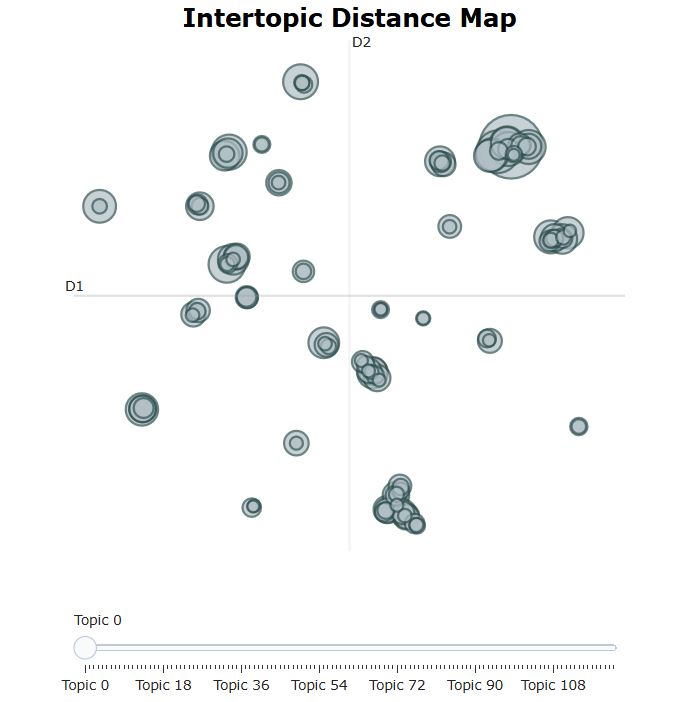

In [60]:
# Loading visualization as an image due to issues with rendering in Github
from IPython.display import Image
Image(filename="positive_static_topic_model_visualize.JPG")

# 3B. Negative Sentiment

In [252]:
# Filter the DataFrame where sentiment_score is less than 0
df_negative_sentiment = df_expanded[df_expanded['sentiment_score'] < 0]

In [253]:
# Use a CountVectorizer to create a bag of words
negative_vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2))  # Unigrams and bigrams
negative_X = negative_vectorizer.fit_transform(df_negative_sentiment['cleaned_comment'])

In [256]:
# Initialize BERTopic
negative_topic_model = BERTopic(language="english", verbose=True)

# Fit the model on the cleaned comments
topics, probabilities = negative_topic_model.fit_transform(df_negative_sentiment['cleaned_comment'])

# Add the topics to the DataFrame
df_negative_sentiment['topic'] = topics

2025-04-25 21:09:21,456 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/127 [00:00<?, ?it/s]

2025-04-25 21:10:03,679 - BERTopic - Embedding - Completed ✓
2025-04-25 21:10:03,680 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-04-25 21:10:29,341 - BERTopic - Dimensionality - Completed ✓
2025-04-25 21:10:29,342 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-04-25 21:10:29,520 - BERTopic - Cluster - Completed ✓
2025-04-25 21:10:29,525 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-04-25 21:10:29,664 - BERTopic - Representation - Completed ✓


In [257]:
# Get the top words for each topic
negative_topics_info = negative_topic_model.get_topic_info()

# Get the most frequent words in the first few topics
top_n = 10  # Adjust as needed
for topic_num in range(top_n):
    print(f"Topic {topic_num}: {negative_topic_model.get_topic(topic_num)}")

Topic 0: [('crime', np.float64(0.021413031337990433)), ('police', np.float64(0.01997487530118144)), ('car', np.float64(0.01832944188763238)), ('steal', np.float64(0.016463241976914057)), ('cops', np.float64(0.01594829018478851)), ('stealing', np.float64(0.015737002202593935)), ('rob', np.float64(0.014917606850471927)), ('riots', np.float64(0.014898958295320132)), ('criminals', np.float64(0.014119086954525253)), ('la', np.float64(0.013888808921610872))]
Topic 1: [('jerseys', np.float64(0.05461277381311568)), ('fanatics', np.float64(0.04893300831712502)), ('mlb', np.float64(0.03778860908408246)), ('logo', np.float64(0.03719710309013784)), ('jersey', np.float64(0.033875534396533895)), ('uniforms', np.float64(0.03014746605723271)), ('nike', np.float64(0.025150524119890376)), ('baseball', np.float64(0.02389943462978315)), ('template', np.float64(0.022475939823329617)), ('year', np.float64(0.017873656866965997))]
Topic 2: [('nike', np.float64(0.040382657509050755)), ('shoes', np.float64(0.02

In [ ]:
# Visualize the topics
# negative_topic_model.visualize_topics()

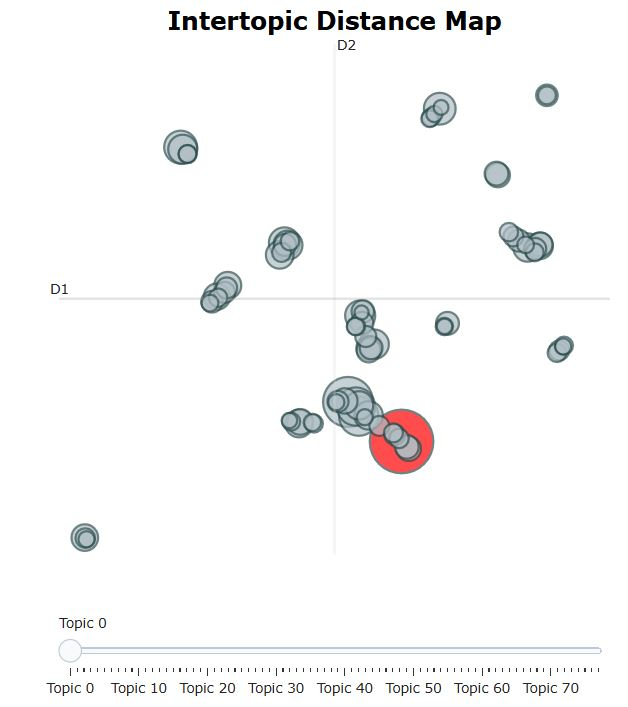

In [59]:
# Loading visualization as an image due to issues with rendering in Github
from IPython.display import Image
Image(filename="negative_static_topic_model_visualize.JPG")

The BERTopic topic modeling has uncovered some intresting points about the positive Reddit comments and the negitive.

The BERTopic topic modeling has uncovered some interesting points about the positive Reddit comments and the negative.  

Positive comments:

1. When focusing on the positive comments, we found that the most common topic (Topic 0) was shoe brand. Specifically, Nike (pretty obvious) and Rebook. Why does this matter? This is a very meaningful finding. This is showing Nike's top competing shoe brand. People on Reddit are not comparing Nike and Hookah, or Nike and Puma, but Nike and Rebook. The fact that no other shoe brands were mentioned in the positive sentiment is powerful. But are these comments saying that Rebook is great or better than Nike? So our model classified it as positive? This is something  we need to look into further to understand.

2. The next most common positive topic (Topic 1) were "kits". In this context, a "kit" refers to the official sports uniforms and related apparel worn by sports players during matches and training. Since this popped up under "positive" sediment, you may assume that people like Nikes kits over Adidas, but upon further investigation, people on Reddit are actually (and quite often) comparing Nike's knits to Adidas. And preferring the Adidas brand. Some comments are "nike is sooo ass when it comes to football kits recently" and "The old Adidas kits have always been soooooo good. Nike have been bland and or straight up bad". This is a great finding and a great thing for Nike to take a look at improving.

3. The 3rd topic was size and fit. Meaning that the brand is doing a good job at producing items that are true to size and fit.

Negative comments:

1. When looking at the top negative comments, the most common topic (Topic 0) was crime. Why? What does crime have to do with the Nike brand? Upon further investigation, we uncovered that it was due to theft of Nike branded items. While this is not inherently good, it also shows how far some are willing to go to try to steal Nike items. Meaning that it is a sot after brand. However, this does not give us much in terms of what changes we can make to improve customer sentiment.

2. The next most common negative topic (Topic 1) was the MLB (a basketball league) meaning that it is important that Nike look into their involvement with this particular sport and it's athletes. There is likely something causing a rift in the fans.

3. The 3rd topic was running. Not a good sign that this is showing under negative sentiment. Some of the comments include "Most Nikes these days are fashion shoes" and "Nike makes the shittiest running shoes. People that actually run would never buy Nike" and "Nike dropped the ball on its heritage running category". All indicating that Nike is no longer known as the "running shoe of choice" as it once was. So what is the take away? Nike needs to start offering better shoes for running and stop focusing so much as the aesthetics (at least for a few shoe options).  


In [13]:
import ipywidgets as widgets

# Print all widget types
for widget_type in widgets.Widget.widget_types:
    print(widget_type)

TypeError: 'WidgetRegistry' object is not iterable